# Winning Without an xG Advantage
### How Positional Structure Separates Winners from Non-Winners in Closely Contested Matches

**Georgia Tech MSA Spring 2026**  
**Team 4:** Alexander Avramov, Noah Boonin, Thomas LaRock  
**Track:** Soccer Analytics Dashboard

---

## Executive Summary

Nearly one in five professional soccer matches features two teams with virtually 
identical expected goals -- and yet someone still won. This analysis asks what 
separated them.

Examining 651 xG-parity matches from the StatsBomb open dataset, we find that 
**positional structure reliably separates winners from non-winners even when chance 
quality cannot.**

**Key Findings:**
1. xG-parity matches are genuinely contested -- draw rates nearly 3× higher than matches where one team dominates on xG (χ² = 132.30, p < 0.0001)
2. Winners hold the ball higher -- 6 of 9 positional groups differ significantly after multiple testing correction
3. Winners move the ball more aggressively forward -- progressive carry distance diverges independently of touch share (Spearman r = -0.086)
4. These signals predict outcomes -- Forward Possession Index achieves AUC = 0.558 across 1,302 team-match observations

**Implications:**  
For coaches and analysts, the implication is straightforward: in 
closely contested matches where chance quality is roughly equal, the team that plays 
higher and moves the ball forward more aggressively tends to win more often. Positional 
structure is not noise, it is signal, and it is exactly the kind of evidence that 
separates tactical intuition from tactical fact.

---

## The Problem With Expected Goals

Every weekend, millions of soccer fans watch matches that often end in ways that defy 
explanation. The better team, by every measurable standard, loses. The underdog 
survives. The analysts shrug and chalk it up to variance, or a specific player.

Expected goals (xG) has become the gold standard for evaluating those measurable 
standards. By assigning a probability to every shot based on its location, angle, 
and context, xG gives us a principled way to separate performance from luck. A team 
that generates 2.5 xG while conceding 0.8 xG probably deserved to win, even if the 
scoreboard says otherwise.

But here is the problem: nearly one in five professional soccer matches features two 
teams with virtually identical xG totals. In those matches, xG has nothing to say. 
Both teams created similar chances. Both teams defended similarly. And yet, someone 
still won.

So what decided it?

That is the question this analysis sets out to answer. Using event-level data from 
651 professional matches where neither team held a meaningful xG advantage, we 
investigate whether **positional structure** can explain what xG cannot.

The short answer is yes. But the full answer is more interesting than that.

We draw on three datasets from StatsBomb's open data library. Match-level records tell 
us who played, what the score was, and which competition the match belonged to. Event-level 
records capture every action taken on the pitch, from passes to carries to shots, each 
tagged with a timestamp, location, and the player responsible. Lineup records connect 
players to their positions within each match.

Together, these three datasets give us everything we need to reconstruct how teams 
structured their play, moment by moment, across thousands of matches.

### Setup: Library Imports

In [88]:
import pandas as pd
import numpy as np
import gc
from pathlib import Path

from scipy.stats import (
    chi2_contingency,
    mannwhitneyu,
    spearmanr,
    wilcoxon,
    f
)
from sklearn.metrics import roc_auc_score

from numpy.linalg import inv

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mplsoccer import Pitch, VerticalPitch


import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully")

Libraries imported successfully


### Setup: Cleanup duties

In [89]:
def keep_only_dataframes(keep_list):

    kept = {}
    
    for name, obj in list(globals().items()):
        if isinstance(obj, pd.DataFrame):
            if name not in keep_list:
                del globals()[name]
            else:
                kept[name] = obj
    
    gc.collect()
    
    print("Kept DataFrames:")
    for name, df in kept.items():
        print(f"{name}: {df.shape}")

### Data Loading

We use **StatsBomb Open Data** containing event-level data from professional soccer matches across multiple competitions and seasons.

**Data Structure:**
- `matches.parquet` - Match-level metadata (teams, scores, competitions)
- `events.parquet` - Event-level data (passes, shots, carries, etc.)
- `lineups.parquet` - Player lineups and positions 
 
From these datasets, we construct team-level features including xG and positional metrics for each match observation.

All feature engineering (xG, positional metrics, progression) is performed below within the notebook pipeline.

In [90]:
# Data directory
DATA_DIR = Path("../data/raw")
STATSBOMB_DIR = DATA_DIR / "Statsbomb"

# Load core datasets
print("Loading StatsBomb data...")

matches = pd.read_parquet(STATSBOMB_DIR / "matches.parquet")
events = pd.read_parquet(STATSBOMB_DIR / "events.parquet")
lineups = pd.read_parquet(STATSBOMB_DIR / "lineups.parquet")

print(f"Loaded {len(matches):,} matches")
print(f"Loaded {len(events):,} events")
print(f"Loaded {len(lineups):,} lineup records")

print(f"\nDataset date range: {matches['match_date'].min()} to {matches['match_date'].max()}")
print(f"Competitions: {matches['competition'].nunique()} unique competitions")

Loading StatsBomb data...
Loaded 3,464 matches
Loaded 12,188,949 events
Loaded 165,820 lineup records

Dataset date range: 1958-06-24 to 2025-07-27
Competitions: 21 unique competitions


In [91]:
keep_only_dataframes(['matches', 'events', 'lineups'])

Kept DataFrames:
matches: (3464, 36)
events: (12188949, 112)
lineups: (165820, 17)


The StatsBomb open dataset covers 3,464 professional matches across 21 competitions, 
spanning nearly seven decades of soccer. Every touch, pass, carry, and shot is recorded 
at the event level, giving us the granularity to examine not just what teams did, but 
where they did it and who was doing it.

That level of detail is exactly what this question demands. Aggregate statistics cannot 
tell us how a team distributed possession across the pitch. Event-level data can.

Before we can study what separates winners from non-winners in close matches, we first 
need to define what a close match actually is, and then confirm our definition 
holds up statistically.

## One in Five Matches Which xG Cannot Explain

Expected goals is a powerful lens, but it has a blind spot. When we examine the 
distribution of xG differences across all 3,464 matches in our dataset, a striking 
pattern emerges: in a substantial share of matches, both teams generated virtually 
identical expected goals totals. The scoreline, however, was rarely a draw.

To study this blind spot systematically, we need a working definition of "close." 
**We define an xG-parity match as one where the absolute difference in total xG between 
the two teams is 0.3 or less.** This threshold is not arbitrary, it represents matches 
where the gap in chance quality is smaller than the value of a single average shot, 
meaning neither team held a meaningful statistical edge in how they attacked.

What we find is that 651 matches, nearly one in five meet this definition. This 
is a large enough sample to study seriously, and a common enough occurrence to matter 
tactically.

But before we ask what separates winners from non-winners in these matches, we should 
ask a more basic question: **are these matches actually more uncertain than others?** If 
xG-parity matches had the same outcome distribution as matches where one team dominated 
on xG, our threshold would be meaningless. Let's find out.

In [92]:
# Isolate shot events and sum xG per team per match
shots = events.loc[events["type"] == "Shot"].copy()

team_match_xg = (
    shots.groupby(["match_id", "team"], as_index=False)
    .agg(
        team_xg=("shot_statsbomb_xg", "sum"),
        shots=("id", "count")
    )
)

# Build team outcomes from match scores
match_outcomes = matches[["match_id", "home_team", "away_team", "home_score", "away_score"]].copy()

home_outcomes = match_outcomes.assign(
    team=match_outcomes["home_team"],
    opponent=match_outcomes["away_team"],
    goals_for=match_outcomes["home_score"],
    goals_against=match_outcomes["away_score"]
)

away_outcomes = match_outcomes.assign(
    team=match_outcomes["away_team"],
    opponent=match_outcomes["home_team"],
    goals_for=match_outcomes["away_score"],
    goals_against=match_outcomes["home_score"]
)

team_outcomes = pd.concat([home_outcomes, away_outcomes], ignore_index=True)

team_outcomes["outcome"] = np.where(
    team_outcomes["goals_for"] > team_outcomes["goals_against"], "Win",
    np.where(
        team_outcomes["goals_for"] < team_outcomes["goals_against"], "Loss",
        "Draw"
    )
)

team_outcomes = team_outcomes[["match_id", "team", "opponent", "outcome"]]

# Merge xG with outcomes
team_match = team_match_xg.merge(
    team_outcomes,
    on=["match_id", "team"],
    how="left"
)

opp_xg = team_match_xg.rename(
    columns={"team": "opponent", "team_xg": "opp_xg"}
)

team_match = team_match.merge(
    opp_xg[["match_id", "opponent", "opp_xg"]],
    on=["match_id", "opponent"],
    how="left"
)

team_match["xg_diff"] = (team_match["team_xg"] - team_match["opp_xg"]).abs()

# Assign xG difference categories
team_match["xg_category"] = "Dominant (>1.5)"
team_match.loc[team_match["xg_diff"] <= 1.5, "xg_category"] = "Moderate (0.7–1.5)"
team_match.loc[team_match["xg_diff"] <= 0.7, "xg_category"] = "Close (0.3–0.7)"
team_match.loc[team_match["xg_diff"] <= 0.3, "xg_category"] = "Parity (≤0.3)"

# display(team_match.sort_values(['match_id']).head(2))
# print(team_match.shape)

In [93]:
match = team_match.drop_duplicates("match_id")

# display(match.sort_values(['match_id']).head(2))
# print(match.shape)

In [94]:
XG_PARITY_THRESHOLD = 0.3

team_match_xg = team_match.loc[team_match["xg_diff"] <= XG_PARITY_THRESHOLD].copy()
team_match_xg = team_match_xg.sort_values(["match_id", "team"]).reset_index(drop=True)

# display(team_match_xg.sort_values(['match_id']).head(2))
# print(team_match_xg.shape)

In [95]:
match_xg = match.loc[match["xg_diff"] <= XG_PARITY_THRESHOLD].copy()

match_xg = match_xg.sort_values(["match_id"]).reset_index(drop=True)
# display(match_xg.sort_values(['match_id']).head(2))
# print(match_xg.shape)

In [96]:
keep_only_dataframes(['matches', 'events', 'lineups', 'team_match', 'match', 'team_match_xg', 'match_xg', 'team_outcomes'])

Kept DataFrames:
matches: (3464, 36)
events: (12188949, 112)
lineups: (165820, 17)
team_match_xg: (1302, 9)
team_outcomes: (6928, 4)
team_match: (6921, 9)
match: (3464, 9)
match_xg: (651, 9)


In [97]:
print(f"Unique matches (total): {(len(match)):,}")
print("\n")
print(f"Match per xG category: ")

display(
    match
    .groupby("xg_category")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\n")
print(f"Unique matches(parity): {len(match_xg)}")
print("\n")
print(f"Percentage: {len(match_xg) / team_match['match_id'].nunique():.2%}")

Unique matches (total): 3,464


Match per xG category: 


,xg_category,count
2,Moderate (0.7–1.5),1127
1,Dominant (>1.5),877
0,Close (0.3–0.7),809
3,Parity (≤0.3),651




Unique matches(parity): 651


Percentage: 18.79%


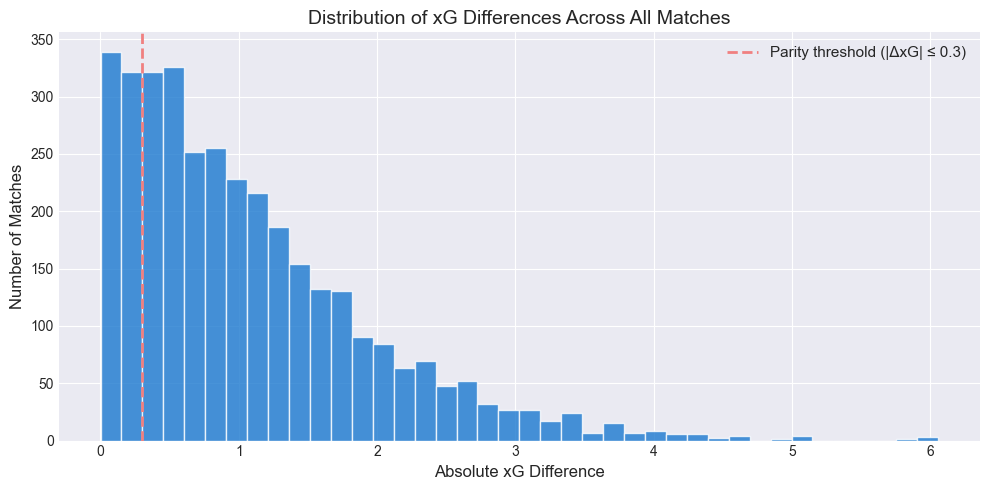

In [98]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(match["xg_diff"], bins=40, color="#1A78CF", alpha=0.8, edgecolor="white")
ax.axvline(XG_PARITY_THRESHOLD, color="lightcoral", linewidth=2, 
           linestyle="--", label=f"Parity threshold (|ΔxG| ≤ {XG_PARITY_THRESHOLD})")

ax.set_xlabel("Absolute xG Difference", fontsize=12)
ax.set_ylabel("Number of Matches", fontsize=12)
ax.set_title("Distribution of xG Differences Across All Matches", fontsize=14)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

To test whether xG-parity matches are genuinely more uncertain than other matches, we 
use a chi-square test of independence. This test asks a simple question: does knowing 
which xG category a match falls into tell us anything about how it ended?

We organize the data into a contingency table containing how many matches for 
each xG category ended in a win, draw, or loss. The chi-square test compares the 
observed counts to what we would expect if outcomes were completely random with respect 
to xG category. A significant result means the two variables are related, not independent.

This test is well-suited here because both variables are categorical, each match appears 
exactly once in the table, and our sample is above the minimum threshold of 5 which 
the test requires to be reliable.

In [99]:
# Test whether outcome distribution depends on xG category
# If parity matches are genuinely different, we expect to reject the null hypothesis
contingency = pd.crosstab(match["xg_category"], match["outcome"])
cat_order = ["Parity (≤0.3)", "Close (0.3–0.7)", "Moderate (0.7–1.5)", "Dominant (>1.5)"]
contingency = contingency.reindex(cat_order)

chi2, p, dof, expected = chi2_contingency(contingency)

# Add totals and draw rate for interpretability
contingency["Total"] = contingency.sum(axis=1)
contingency["Draw Rate"] = (contingency["Draw"] / contingency["Total"]).round(3)

print("Match Outcome by xG Difference Category")
print("=" * 65)
print(contingency.to_string())
print(f"\nχ² = {chi2:.2f}, df = {dof}, p < 0.0001")

Match Outcome by xG Difference Category
outcome             Draw  Loss  Win  Total  Draw Rate
xg_category                                          
Parity (≤0.3)        194   202  255    651      0.298
Close (0.3–0.7)      240   268  301    809      0.297
Moderate (0.7–1.5)   266   372  489   1127      0.236
Dominant (>1.5)       97   274  506    877      0.111

χ² = 132.30, df = 6, p < 0.0001


The numbers are unambiguous. A chi-square test of independence confirms that outcome 
distribution varies significantly across xG categories (χ² = 132.30, p < 0.0001). But 
the most telling statistic is simpler than that: in xG-parity matches, nearly one in 
three matches ends in a draw. In matches where one team dominates on xG, that figure 
drops to one in nine.

Parity matches are genuinely uncertain. The 0.3 threshold is doing real work.

One honest nuance worth noting: the draw rate in parity matches (29.8%) is nearly 
identical to close matches (29.7%). The meaningful drop-off happens when xG differences 
exceed 0.7, not precisely at 0.3. Our threshold captures genuinely contested matches, 
but it is not uniquely magical. What matters is that within this subset, outcomes are 
demonstrably uncertain, yet someone still won. This is what we want to understand.

With the sample validated, we can now ask the real question: **in these 651 matches where 
chance quality was equal, what did the winning teams do differently**?

## Where Winners Play

Imagine watching two matches side by side. In both, the teams are evenly matched on 
paper: similar xG, similar shot counts, similar defensive records. But in one match, 
the winning team spends the majority of their possession in advanced areas, recycling 
the ball through their attacking midfielders and wide forwards, constantly threatening 
the space behind the defensive line. In the other, the winning team is more conservative, 
comfortable holding the ball deeper and playing it safe.

Are these genuinely different styles of winning, or does it not matter where on the 
pitch you hold the ball, as long as you hold it?

This question sits at the heart of our analysis. We know xG-parity matches are 
genuinely uncertain. What we do not yet know is whether the teams which win xG-parity matches share 
any structural characteristics or patterns in how they organize possession to separate 
them from the teams which draw or lose.

To investigate this, we turn to a deceptively simple concept: **positional touch share**.

Every touch a player takes, whether receiving a pass, carrying the ball, or shooting,  
happens somewhere on the pitch, and is tied to the player's position. A 
center back touching the ball is a very different tactical event than an attacking 
midfielder touching it, even if the raw count is the same.

Positional touch share captures this distinction. For each team in each match, we 
calculate what proportion of the team's total touches were taken by players in each 
positional group. A team with a touch share of 15% at attacking midfield is allocating 
a meaningful slice of its possession to its most advanced creative players. A team at 
9% in the same position is keeping the ball much deeper.

This normalization is important. We are not measuring how much a team possesses the 
ball in total, **we are measuring where they possess it**. A team which dominates 
possession but concentrates it defensively looks very different from one which circulates 
the ball in advanced areas, even if their total touch counts are identical.

We therefore group StatsBomb's granular position labels into nine positional bins: Goalkeeper, 
Center Back, Fullback, Defensive Midfield, Central Midfield, Wide Midfield, Attacking 
Midfield, Wide Forward, and Striker, then compute touch share for each team in each 
of our 651 parity matches, giving us 1,302 team-match observations to work with.

In [100]:
xg_parity_match_ids = match_xg["match_id"].unique()

events_parity = events[events["match_id"].isin(xg_parity_match_ids)].copy()

TOUCH_EVENTS = [
    "Ball Receipt*",
    "Pass",
    "Carry",
    "Dribble",
    "Shot"
]

touches = events_parity[events_parity["type"].isin(TOUCH_EVENTS)].copy()

POSITION_BIN_MAP = {

    # Goalkeeper
    "Goalkeeper": "Goalkeeper",
    
    # Center Backs
    "Center Back": "Center Back",
    "Left Center Back": "Center Back",
    "Right Center Back": "Center Back",
    
    # Fullbacks
    "Left Back": "Fullback",
    "Right Back": "Fullback",
    "Left Wing Back": "Fullback",
    "Right Wing Back": "Fullback",
    
    # Defensive Midfield
    "Center Defensive Midfield": "Defensive Midfield",
    "Left Defensive Midfield": "Defensive Midfield",
    "Right Defensive Midfield": "Defensive Midfield",
    
    # Central Midfield
    "Center Midfield": "Central Midfield",
    "Left Center Midfield": "Central Midfield",
    "Right Center Midfield": "Central Midfield",
    
    # Attacking Midfield
    "Center Attacking Midfield": "Attacking Midfield",
    "Left Attacking Midfield": "Attacking Midfield",
    "Right Attacking Midfield": "Attacking Midfield",
    
    # Wide Midfield
    "Left Midfield": "Wide Midfield",
    "Right Midfield": "Wide Midfield",
    
    # Wide Forward
    "Left Wing": "Wide Forward",
    "Right Wing": "Wide Forward",
    
    # Striker
    "Center Forward": "Striker",
    "Left Center Forward": "Striker",
    "Right Center Forward": "Striker",
    "Secondary Striker": "Striker",
}

touches["position_bin"] = touches["position"].map(POSITION_BIN_MAP)

touches = touches.dropna(subset=["position_bin"])

team_match_position_touches = (
    touches
    .groupby(["match_id", "team", "position_bin"])
    .size()
    .reset_index(name="touches")
)

team_match_totals = (
    team_match_position_touches
    .groupby(["match_id", "team"])["touches"]
    .sum()
    .reset_index(name="team_touches")
)

team_match_position_touches = team_match_position_touches.merge(
    team_match_totals,
    on=["match_id", "team"],
    how="left"
)

team_match_position_touches["touch_share"] = (
    team_match_position_touches["touches"] /
    team_match_position_touches["team_touches"]
)

team_match_position_touches = team_match_position_touches.merge(
    team_match_xg[["match_id", "team", "outcome"]],
    on=["match_id", "team"],
    how="left"
)

team_match_position_touches["outcome_binary"] = np.where(
    team_match_position_touches["outcome"] == "Win",
    "Win",
    "Non-Win"
)

# display(team_match_position_touches.head(2))
# print(team_match_position_touches.shape)

print(f"Parity match IDs: {len(xg_parity_match_ids):,}")
print(f"Team-match-position observations: {len(team_match_position_touches):,}")
print(f"Unique positions: {sorted(team_match_position_touches['position_bin'].unique())}")
print(f"\nOutcome distribution:")
print(team_match_position_touches.drop_duplicates(['match_id','team'])['outcome_binary'].value_counts())

Parity match IDs: 651
Team-match-position observations: 9,207
Unique positions: ['Attacking Midfield', 'Center Back', 'Central Midfield', 'Defensive Midfield', 'Fullback', 'Goalkeeper', 'Striker', 'Wide Forward', 'Wide Midfield']

Outcome distribution:
outcome_binary
Non-Win    845
Win        457
Name: count, dtype: int64


With touch share computed for all 1,302 team-match observations, we can now ask whether 
winning teams distribute possession differently across positions compared to non-winning 
teams.

We use the Mann-Whitney U test, a nonparametric test that asks a subtle but powerful 
question: if you randomly selected one winning team-match and one non-winning team-match, 
which group tends to have higher touch share at each position? Unlike simpler comparisons 
of averages, the Mann-Whitney U test makes no assumptions about the shape of the underlying distribution, 
making it well suited for bounded metrics like touch share.

We run this test separately for each of the nine positional bins, comparing winners 
against non-winners across all 651 parity matches.

In [101]:
positions = sorted(team_match_position_touches['position_bin'].unique())

wins = team_match_position_touches[team_match_position_touches['outcome_binary'] == 'Win']
nonwins = team_match_position_touches[team_match_position_touches['outcome_binary'] == 'Non-Win']

results = []
for position in positions:
    win_shares = wins[wins['position_bin'] == position]['touch_share']
    nonwin_shares = nonwins[nonwins['position_bin'] == position]['touch_share']
    
    u_stat, p_val = mannwhitneyu(win_shares, nonwin_shares, alternative='two-sided')
    
    win_mean = win_shares.mean()
    nonwin_mean = nonwin_shares.mean()
    diff = win_mean - nonwin_mean
    
    results.append({
        'Position': position,
        'Win Mean': round(win_mean, 4),
        'Non-Win Mean': round(nonwin_mean, 4),
        'Difference': round(diff, 4),
        'U Statistic': round(u_stat, 1),
        'p-value': round(p_val, 4),
        'Significant': '✅' if p_val < 0.05 else '❌'
    })

mw_results = pd.DataFrame(results).sort_values('Difference', ascending=False)
print("Mann-Whitney U Test: Touch Share by Position (Win vs. Non-Win)")
print("=" * 70)
print(mw_results.to_string(index=False))
print(f"\nSignificant positions (p < 0.05): {mw_results['Significant'].eq('✅').sum()}/9")

Mann-Whitney U Test: Touch Share by Position (Win vs. Non-Win)
          Position  Win Mean  Non-Win Mean  Difference  U Statistic  p-value Significant
Attacking Midfield    0.1058        0.0903      0.0155      65242.5   0.0002           ✅
     Wide Midfield    0.1654        0.1528      0.0126      33353.0   0.0429           ✅
      Wide Forward    0.1741        0.1617      0.0124      85302.0   0.0009           ✅
           Striker    0.1171        0.1119      0.0052     201868.5   0.1749           ❌
        Goalkeeper    0.0497        0.0460      0.0038     219014.5   0.0001           ✅
  Central Midfield    0.1782        0.1747      0.0036      68170.0   0.2220           ❌
          Fullback    0.1881        0.1937     -0.0055     171911.0   0.0019           ✅
       Center Back    0.1713        0.1804     -0.0091     174002.0   0.0032           ✅
Defensive Midfield    0.1559        0.1666     -0.0107     149582.0   0.0051           ✅

Significant positions (p < 0.05): 7/9


The results paint a clear and directional picture. Seven of nine positions show 
statistically significant differences between winning and non-winning teams, and 
the pattern runs consistently from one end of the pitch to the other.

**Winning teams allocate more touches to their attacking midfielders, wide forwards, 
and interestingly, their goalkeepers.** Non-winning teams concentrate more possession 
in their defensive and midfield structure (center backs, defensive midfielders, and 
fullbacks). The two positions which show no significant difference, Striker and Central 
Midfield, sit in the middle of this spectrum, suggesting they serve similar functions 
regardless of outcome.

This is a consistent, directional shift in how possession is organized across the 
entire pitch. **Winning teams in xG-parity matches play higher.**

However, before accepting these results, we need to address a methodological concern 
about the structure of our data.

### Robustness Check: Accounting for Match-Level Correlation

Before accepting the Mann-Whitney results at face value, it is worth examining a 
methodological concern. Our dataset contains two observations per match, one for 
each team. This means our 1,302 team-match observations are not fully independent. 
If Team A wins, Team B does not. The outcomes are linked by definition, and standard 
statistical tests like Mann-Whitney U assume that each observation is an independent 
draw from the population.

In practice this means our p-values could be artificially inflated, appearing more 
significant than they would be if we had 1,302 truly independent matches rather than 
651 matched pairs.

A cleaner approach is to embrace the paired structure of the data rather than ignore 
it. For each of our 651 matches, we compute the difference in touch share between the 
winning team and the non-winning team at each position. This gives us 651 paired 
differences per position (one per match) and we can test whether those differences 
are systematically positive or negative using the Wilcoxon signed-rank test, the 
nonparametric equivalent of a paired t-test.

This approach is stronger than simply subsampling one team per match. It uses 
all 651 matches, directly controls for match-level confounds that affect both teams 
equally, and removes between-match noise by focusing on within-match differences. If 
our findings are real, they should survive this stricter test.

In [102]:
# Build match-level paired differences for touch share
touch_wide_paired = (
    team_match_position_touches
    .pivot_table(
        index=["match_id", "position_bin"],
        columns="outcome_binary",
        values="touch_share",
        aggfunc="mean"
    )
    .reset_index()
    .dropna(subset=["Win", "Non-Win"])
)

touch_wide_paired["difference"] = (
    touch_wide_paired["Win"] - touch_wide_paired["Non-Win"]
)

# Wilcoxon signed-rank test by position
print("Wilcoxon Signed-Rank Test: Paired Touch Share Differences")
print("=" * 65)

paired_results = []
for position in positions:
    pos_data = touch_wide_paired[
        touch_wide_paired["position_bin"] == position
    ]["difference"].dropna()
    
    if len(pos_data) < 10:
        continue
    
    stat, p_val = wilcoxon(pos_data)
    
    paired_results.append({
        "Position": position,
        "Mean Difference": round(pos_data.mean(), 4),
        "Wilcoxon p-value": round(p_val, 4),
        "Significant": "✅" if p_val < 0.05 else "❌",
        "Survives Bonferroni": "✅" if p_val < (0.05 / len(positions)) else "❌"
    })

paired_df = pd.DataFrame(paired_results).sort_values(
    "Mean Difference", ascending=False
)
print(paired_df.to_string(index=False))

Wilcoxon Signed-Rank Test: Paired Touch Share Differences
          Position  Mean Difference  Wilcoxon p-value Significant Survives Bonferroni
Attacking Midfield           0.0238            0.0000           ✅                   ✅
     Wide Midfield           0.0191            0.1991           ❌                   ❌
      Wide Forward           0.0187            0.0005           ✅                   ✅
  Central Midfield           0.0094            0.2378           ❌                   ❌
           Striker           0.0093            0.0399           ✅                   ❌
        Goalkeeper           0.0039            0.0016           ✅                   ✅
          Fullback          -0.0081            0.0001           ✅                   ✅
Defensive Midfield          -0.0098            0.0087           ✅                   ❌
       Center Back          -0.0163            0.0000           ✅                   ✅


The robustness check is reassuring. Five positions survive Bonferroni correction under 
both tests, and the directional pattern holds without exception -- every position that 
was positive under Mann-Whitney remains positive under Wilcoxon, and every negative 
remains negative. The independence correction does not change the story. It confirms it.

With the findings validated under two methodological approaches, we can now ask the 
next question with confidence: **how large are these differences, really**?

Statistical significance tells us that a difference is unlikely to be due to chance. 
It does not tell us if the difference is large enough to matter in practice. 
With over 1,300 observations, even a trivially small difference in touch share could 
produce a significant p-value simply because we have so much data to work with.

To address this, we calculate Cohen's d, a standardized measure of effect size that 
expresses the difference between two groups in terms of the natural variation in the 
data. A value near zero means the groups are practically indistinguishable despite any 
statistical significance. Larger values indicate more meaningful separation.

Convention interprets Cohen's d as follows:

- Below 0.2 -- negligible, the groups are essentially the same
- 0.2 to 0.5 -- small, a real but subtle difference
- 0.5 to 0.8 -- medium, a clearly noticeable difference
- Above 0.8 -- large, a substantial difference

In a sport as complex and low-scoring as soccer, we would not expect large effect sizes 
for any single tactical metric. Even small effects, if consistent and robust, are 
meaningful. What we are looking for is whether the positional differences we found are 
real in a practical sense, not just a statistical one.

In [103]:
def cohens_d(group1, group2):
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    return (group1.mean() - group2.mean()) / pooled_std

effect_sizes = []
for position in positions:
    win_shares = wins[wins['position_bin'] == position]['touch_share']
    nonwin_shares = nonwins[nonwins['position_bin'] == position]['touch_share']
    
    d = cohens_d(win_shares, nonwin_shares)
    
    if abs(d) >= 0.8:
        magnitude = 'Large'
    elif abs(d) >= 0.5:
        magnitude = 'Medium'
    elif abs(d) >= 0.2:
        magnitude = 'Small'
    else:
        magnitude = 'Negligible'
    
    effect_sizes.append({
        'Position': position,
        'Cohen\'s d': round(d, 4),
        'Magnitude': magnitude,
    })

cd_results = pd.DataFrame(effect_sizes).sort_values('Cohen\'s d', ascending=False)
print("Cohen's d Effect Sizes: Touch Share by Position (Win vs. Non-Win)")
print("=" * 55)
print(cd_results.to_string(index=False))

Cohen's d Effect Sizes: Touch Share by Position (Win vs. Non-Win)
          Position  Cohen's d  Magnitude
Attacking Midfield     0.3527      Small
      Wide Forward     0.2106      Small
        Goalkeeper     0.2028      Small
     Wide Midfield     0.1688 Negligible
           Striker     0.1018 Negligible
  Central Midfield     0.0508 Negligible
       Center Back    -0.1456 Negligible
Defensive Midfield    -0.1767 Negligible
          Fullback    -0.1866 Negligible


The effect sizes confirm what the Mann-Whitney results suggested, but with an important 
qualification. Attacking Midfield leads with a Cohen's d of 0.35, a small but genuine 
effect. Wide Forward and Goalkeeper follow at 0.21 and 0.20 respectively, both just 
crossing the threshold into meaningful territory. The remaining positions fall below 0.2, 
classified as negligible by convention.

This is an honest result. The differences between winning and non-winning teams in 
xG-parity matches are real, but they are subtle. No single position dramatically 
separates the two groups. What we are seeing is a pattern of small, consistent shifts 
across the pitch rather than one decisive tactical difference.

In soccer terms, this makes intuitive sense. No coach wins matches by radically 
repositioning their team's possession structure. The margins are fine, the adjustments 
are incremental, and the cumulative effect of several small positional shifts is what 
adds up to a meaningful difference in outcomes.

We have established that the differences are real and modest in size. 
There is one more question worth asking before we move on: **can we trust these results, 
given that we tested nine positions simultaneously**?

When we run nine separate statistical tests at once, we introduce a subtle but important 
problem. Each test carries a 5% chance of producing a false positive, a result that 
looks significant but is actually just noise. Run enough tests and false positives become 
inevitable.

The math is straightforward. If each test has a 95% chance of not producing a false 
positive, then the probability of getting clean results across all nine tests is 
0.95 multiplied by itself nine times -- 0.95⁹ -- which comes out to about 0.63. That 
means there is a 37% chance of getting at least one spurious significant result purely 
by chance, even if nothing real is going on. Nearly two in five analyses of this kind 
would produce at least one false discovery without any correction.

This is known as the multiple comparisons problem, and it is one of the most common 
sources of unreliable findings in data analysis.

Bonferroni correction is a straightforward solution. Rather than accepting results at the 
standard significance threshold of 0.05, we divide that threshold by the number of tests 
we ran (in this case nine) giving us an adjusted threshold of 0.0056. Only positions 
whose p-values fall below this stricter standard earn our confidence.

This is a deliberately conservative approach. Some genuine effects will not survive it. 
But the positions which do survive are ones we can point to with real confidence, knowing 
they are not artifacts of running multiple tests simultaneously.

In [104]:
ALPHA = 0.05
n_tests = len(positions)
bonferroni_alpha = ALPHA / n_tests

# bonferroni_results = mw_results.copy()
bonferroni_results = mw_results.merge(cd_results, on="Position")
bonferroni_results['Survives Bonferroni'] = bonferroni_results['p-value'].apply(
    lambda p: '✅' if p < bonferroni_alpha else '❌'
)

print(f"Bonferroni Correction: α = {ALPHA} / {n_tests} tests = {bonferroni_alpha:.4f}")
print("=" * 75)
# print(bonferroni_results[['Position', 'p-value', 'Significant', 'Survives Bonferroni']].to_string(index=False))

print(
    bonferroni_results[[
        "Position", "Win Mean", "Non-Win Mean", "Difference", 
        "p-value", "Cohen's d", "Magnitude", "Survives Bonferroni"
    ]].to_string(index=False)
)
print(f"\nPositions surviving Bonferroni: {bonferroni_results['Survives Bonferroni'].eq('✅').sum()}/{n_tests}")

Bonferroni Correction: α = 0.05 / 9 tests = 0.0056
          Position  Win Mean  Non-Win Mean  Difference  p-value  Cohen's d  Magnitude Survives Bonferroni
Attacking Midfield    0.1058        0.0903      0.0155   0.0002     0.3527      Small                   ✅
     Wide Midfield    0.1654        0.1528      0.0126   0.0429     0.1688 Negligible                   ❌
      Wide Forward    0.1741        0.1617      0.0124   0.0009     0.2106      Small                   ✅
           Striker    0.1171        0.1119      0.0052   0.1749     0.1018 Negligible                   ❌
        Goalkeeper    0.0497        0.0460      0.0038   0.0001     0.2028      Small                   ✅
  Central Midfield    0.1782        0.1747      0.0036   0.2220     0.0508 Negligible                   ❌
          Fullback    0.1881        0.1937     -0.0055   0.0019    -0.1866 Negligible                   ✅
       Center Back    0.1713        0.1804     -0.0091   0.0032    -0.1456 Negligible                

Six of nine positions survive the stricter Bonferroni threshold, and the pattern they 
form tells a coherent tactical story.

On one side, winning teams allocate significantly more possession to their attacking 
midfielders and wide forwards. These players are most responsible for creating danger in 
and around the opposition's penalty area. On the other side, non-winning teams 
concentrate more possession in their center backs, defensive midfielders, and fullbacks: 
the players whose primary job is to protect and recycle, not to threaten.

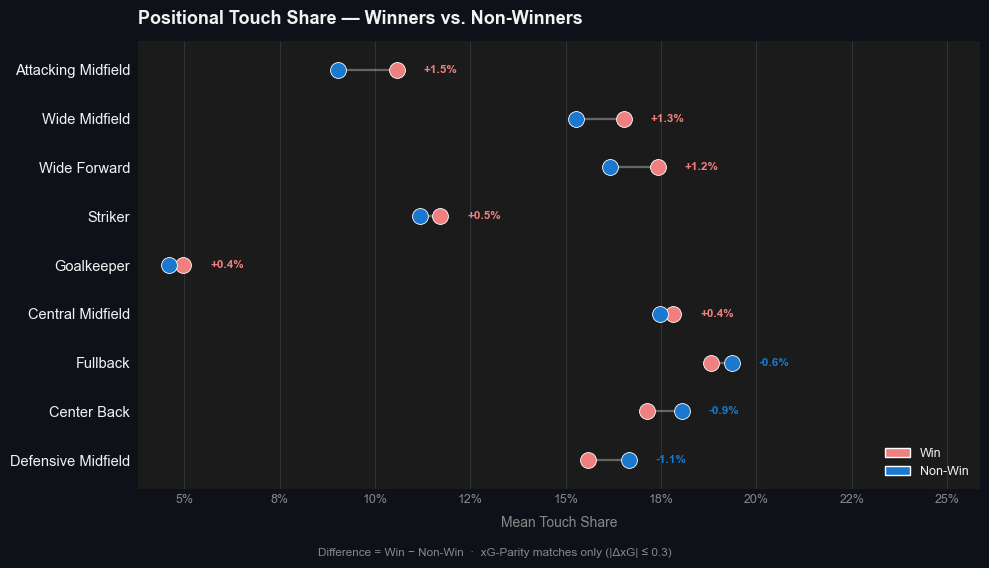

In [105]:
# ── Palette ───────────────────────────────────────────────────────────────────
BG_DARK   = "#0E1117"
BG_PANEL  = "#1B1B1B"
CORAL     = "lightcoral"
BLUE      = "#1A78CF"
WHITE     = "#F2F2F2"
GREY      = "#888888"
SPINE_COL = "#2E323A"

# ── Aggregate from touches_pd (computed in Section 2) ─────────────────────────
touch_agg = (
    team_match_position_touches
    .groupby(["position_bin", "outcome_binary"])["touch_share"]
    .mean()
    .unstack()
    .reset_index()
)
touch_agg = touch_agg.rename(columns={"Non-Win": "Non_Win"})
touch_agg["diff"] = touch_agg["Win"] - touch_agg["Non_Win"]
touch_agg = touch_agg.sort_values("diff", ascending=True)

positions = touch_agg["position_bin"].tolist()
n = len(positions)

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

all_x = list(touch_agg["Win"]) + list(touch_agg["Non_Win"])
ax.set_xlim(min(all_x) - 0.008, max(all_x) + 0.065)

ax.grid(axis="x", color=SPINE_COL, lw=0.7, zorder=0)
ax.grid(axis="y", visible=False)
for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COL)

for i, row in enumerate(touch_agg.itertuples()):
    bw, bn, diff = row.Win, row.Non_Win, row.diff
    ax.plot([bw, bn], [i, i], color=WHITE, lw=1.6, alpha=0.35, zorder=2)
    ax.scatter(bw, i, color=CORAL, s=130, zorder=4, edgecolors="white", linewidths=0.6)
    ax.scatter(bn, i, color=BLUE,  s=130, zorder=4, edgecolors="white", linewidths=0.6)
    sign  = "+" if diff >= 0 else ""
    label = f"{sign}{diff*100:.1f}%"
    col   = CORAL if diff > 0 else (BLUE if diff < 0 else GREY)
    ax.text(max(bw, bn) + 0.007, i, label,
            va="center", ha="left", fontsize=8.5,
            color=col, fontweight="bold", zorder=5)

ax.set_yticks(range(n))
ax.set_yticklabels(positions, color=WHITE, fontsize=10.5)
ax.set_ylim(-0.6, n - 0.4)
ax.tick_params(axis="y", length=0, pad=6)
ax.tick_params(axis="x", colors=GREY, labelsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel("Mean Touch Share", color=GREY, fontsize=10, labelpad=7)

ax.set_title(
    "Positional Touch Share — Winners vs. Non-Winners",
    color=WHITE, fontsize=13, fontweight="bold", loc="left", pad=12,
)
fig.text(0.5, -0.02,
    "Difference = Win − Non-Win  ·  xG-Parity matches only (|ΔxG| ≤ 0.3)",
    ha="center", color=GREY, fontsize=8.5)

legend_handles = [
    mpatches.Patch(facecolor=CORAL, edgecolor="white", label="Win"),
    mpatches.Patch(facecolor=BLUE,  edgecolor="white", label="Non-Win"),
]
ax.legend(handles=legend_handles, loc="lower right",
          framealpha=0.15, facecolor=BG_PANEL,
          labelcolor=WHITE, fontsize=9, edgecolor=SPINE_COL)

plt.tight_layout()
plt.show()

The chart makes the pattern impossible to miss. But it is worth noting what the 
visualization also shows in the middle of the chart -- Wide Midfield, Striker, and 
Central Midfield cluster close to zero. These positions did not survive our corrections, 
and the chart shows why: the differences are negligible. They occupy the transitional 
zones of the pitch and appear to serve similar functions regardless of outcome.

What emerges is not a single tactical smoking gun but a coherent structural pattern. 
**Winning teams in xG-parity matches play higher.** They shift possession away from 
defensive areas and into advanced ones, and they do so consistently enough across 651 
matches that the signal survives even our most conservative statistical test.

This raises a natural follow-up question. We now know where winning teams hold the ball. 
But do they also move it differently? Holding possession in advanced areas and actively 
driving the ball forward are related ideas, but they are not the same thing. A team can 
position its attacking midfielders high without those players carrying the ball 
aggressively toward goal and vice versa.

That distinction is what we examine next.

## How Winners Move

Knowing where a team holds the ball is one dimension of tactical structure. Knowing 
what they do with it is another.

Consider two teams with identical attacking midfield touch shares. One team's attacking 
midfielders receive the ball and immediately look to drive forward, consistently gaining 
ground toward the opposition goal with every carry. The other team's attacking 
midfielders receive, hold, and recycle, maintaining possession but not advancing it. 
Same position, same touch share, very different tactical intent.

This distinction matters because soccer is not just about where you are on the pitch, 
it is about what you do when you get there. A team which positions itself high but plays 
cautiously is tactically different from one that positions itself high and drives forward 
aggressively. If both behaviors are associated with winning, they are telling us the same 
story. If they are independent of each other, they are telling us two different stories 
that together paint a richer picture of what separates winners from non-winners.

To explore this, we turn to progressive carry distance, the measure of how many yards 
a player gains toward the opponent's goal with each ball carry. A positive value means 
the player drove forward. A negative value means they carried backward. Aggregated 
across positions and matches, this metric captures not just where teams play, but how 
aggressively they advance the ball when they have it.

We focus specifically on carries rather than all progressive actions for a deliberate 
reason. A progressive pass tells us something about a team's intent, but passing is a 
collaborative action where one player decides to play the pass, another decides where to 
run. A carry is different. When a player picks up the ball and drives forward, that is 
an individual decision made in real time, reflecting both the player's role and the 
team's broader tactical posture in that moment.

Carries are also more spatially precise than passes. A pass can travel thirty yards 
in an instant, making it harder to attribute the progression to a specific tactical 
structure. A carry unfolds gradually, step by step, and the distance gained is a direct 
reflection of how aggressively that player, and by extension the specific positional unit, 
is pushing forward.

For each carry in our 651 parity matches, we calculate the difference between where 
the carry started and where it ended along the length of the pitch. We then aggregate 
this into a mean progressive carry distance for each positional group within each 
team-match, giving us a positional profile of forward aggression that mirrors the 
touch share profile we built in the previous section.

The question is whether these two profiles tell the same story or different ones.

In [106]:
# Filter to carry events in parity matches
carries = (
    events[
        (events["match_id"].isin(xg_parity_match_ids)) &
        (events["type"] == "Carry") &
        (events["position"].notna())
    ]
    .copy()
)

# Map position bins
carries["position_bin"] = carries["position"].map(POSITION_BIN_MAP)
carries = carries.dropna(subset=["position_bin"])

# Compute progressive distance
carries["progressive_distance"] = (
    carries["carry_end_location_x"] - carries["location_x"]
)

# Aggregate mean progressive distance by team-match-position
team_match_prog = (
    carries
    .groupby(["match_id", "team", "position_bin"], as_index=False)
    .agg(mean_prog_distance=("progressive_distance", "mean"))
)

# Join outcomes
team_match_prog = team_match_prog.merge(
    team_outcomes,
    on=["match_id", "team"],
    how="left"
)

# Create binary outcome
team_match_prog["outcome_binary"] = np.where(
    team_match_prog["outcome"] == "Win",
    "Win",
    "Non-Win"
)

# Keep same naming for downstream compatibility
carries_pd = team_match_prog.copy()

print(f"Team-match-position observations: {len(carries_pd):,}")
print(f"Unique positions: {sorted(carries_pd['position_bin'].unique())}")

print(f"\nOutcome distribution:")
team_match_check = carries_pd.drop_duplicates(subset=["match_id", "team"])
print(f"Total unique team-matches: {len(team_match_check):,}")
print(team_match_check["outcome_binary"].value_counts())


Team-match-position observations: 9,196
Unique positions: ['Attacking Midfield', 'Center Back', 'Central Midfield', 'Defensive Midfield', 'Fullback', 'Goalkeeper', 'Striker', 'Wide Forward', 'Wide Midfield']

Outcome distribution:
Total unique team-matches: 1,302
outcome_binary
Non-Win    845
Win        457
Name: count, dtype: int64


With progressive carry distance computed for each positional group, we can compare 
winning and non-winning teams directly. Rather than running the full statistical battery 
again, we focus on the directional pattern first. Does the picture resemble what we 
saw with touch share, or does it tell a different story?

In [107]:
# Summary comparison of progressive distance by position and outcome
prog_summary = (
    carries_pd
    .groupby(['position_bin', 'outcome_binary'])['mean_prog_distance']
    .mean()
    .unstack()
    .round(4)
)

prog_summary['Difference'] = (prog_summary['Win'] - prog_summary['Non-Win']).round(4)
prog_summary = prog_summary.sort_values('Difference', ascending=False)

print("Mean Progressive Carry Distance by Position (Win vs. Non-Win)")
print("=" * 65)
print(prog_summary.to_string())

Mean Progressive Carry Distance by Position (Win vs. Non-Win)
outcome_binary      Non-Win     Win  Difference
position_bin                                   
Wide Midfield        3.5862  4.0985      0.5123
Striker              2.1825  2.5801      0.3976
Wide Forward         3.3110  3.6632      0.3522
Attacking Midfield   2.5655  2.8516      0.2861
Fullback             2.8625  2.8379     -0.0246
Goalkeeper           3.0378  2.9904     -0.0474
Central Midfield     2.4240  2.3453     -0.0787
Defensive Midfield   1.9581  1.7326     -0.2255
Center Back          2.5860  2.2966     -0.2894


The pattern is familiar in direction but different in detail. Attacking positions 
(Wide Midfield, Striker, Wide Forward, and Attacking Midfield) all show positive 
differences, meaning winners carry more aggressively forward in these areas. Defensive 
positions (Center Back, Defensive Midfield) show negative differences, meaning 
winners actually carry less aggressively from deep.

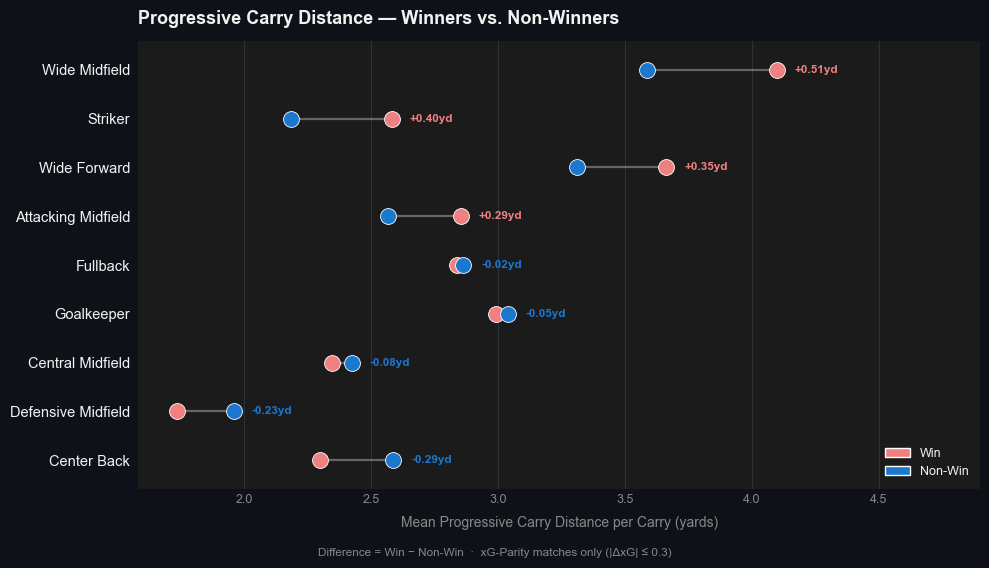

In [108]:
# ── Palette ───────────────────────────────────────────────────────────────────
BG_DARK   = "#0E1117"
BG_PANEL  = "#1B1B1B"
CORAL     = "lightcoral"
BLUE      = "#1A78CF"
WHITE     = "#F2F2F2"
GREY      = "#888888"
SPINE_COL = "#2E323A"

# ── Aggregate from carries_pd (computed in Section 3) ─────────────────────────
# carries_pd has: match_id, team, position_bin, mean_prog_distance, outcome, outcome_binary
dist_agg = (
    carries_pd
    .groupby(["position_bin", "outcome_binary"])["mean_prog_distance"]
    .mean()
    .unstack()
    .reset_index()
)
dist_agg = dist_agg.rename(columns={"Non-Win": "Non_Win"})
dist_agg["diff"] = dist_agg["Win"] - dist_agg["Non_Win"]
dist_agg = dist_agg.sort_values("diff", ascending=True)

positions = dist_agg["position_bin"].tolist()
n = len(positions)

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

all_x = list(dist_agg["Win"]) + list(dist_agg["Non_Win"])
ax.set_xlim(min(all_x) - 0.15, max(all_x) + 0.8)

ax.grid(axis="x", color=SPINE_COL, lw=0.7, zorder=0)
ax.grid(axis="y", visible=False)
for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COL)

for i, row in enumerate(dist_agg.itertuples()):
    bw, bn, diff = row.Win, row.Non_Win, row.diff
    ax.plot([bw, bn], [i, i], color=WHITE, lw=1.6, alpha=0.35, zorder=2)
    ax.scatter(bw, i, color=CORAL, s=130, zorder=4, edgecolors="white", linewidths=0.6)
    ax.scatter(bn, i, color=BLUE,  s=130, zorder=4, edgecolors="white", linewidths=0.6)
    sign  = "+" if diff >= 0 else ""
    label = f"{sign}{diff:.2f}yd"
    col   = CORAL if diff > 0 else (BLUE if diff < 0 else GREY)
    ax.text(max(bw, bn) + 0.07, i, label,
            va="center", ha="left", fontsize=8.5,
            color=col, fontweight="bold", zorder=5)

ax.set_yticks(range(n))
ax.set_yticklabels(positions, color=WHITE, fontsize=10.5)
ax.set_ylim(-0.6, n - 0.4)
ax.tick_params(axis="y", length=0, pad=6)
ax.tick_params(axis="x", colors=GREY, labelsize=9)
ax.set_xlabel("Mean Progressive Carry Distance per Carry (yards)", color=GREY, fontsize=10, labelpad=7)

ax.set_title(
    "Progressive Carry Distance — Winners vs. Non-Winners",
    color=WHITE, fontsize=13, fontweight="bold", loc="left", pad=12,
)
fig.text(0.5, -0.02,
    "Difference = Win − Non-Win  ·  xG-Parity matches only (|ΔxG| ≤ 0.3)",
    ha="center", color=GREY, fontsize=8.5)

legend_handles = [
    mpatches.Patch(facecolor=CORAL, edgecolor="white", label="Win"),
    mpatches.Patch(facecolor=BLUE,  edgecolor="white", label="Non-Win"),
]
ax.legend(handles=legend_handles, loc="lower right",
          framealpha=0.15, facecolor=BG_PANEL,
          labelcolor=WHITE, fontsize=9, edgecolor=SPINE_COL)

plt.tight_layout()
plt.show()

The chart reinforces the table but adds something the numbers alone cannot 
convey: the consistency of the pattern across the pitch. Every attacking position sits to the 
right for winners. Every defensive position sits to the left.

But look more closely at two positions that behave differently here than they did in 
the touch share analysis. Goalkeeper, which showed a significant positive difference 
in touch share, flips negative in progressive distance. Winners have slightly less 
progressive goalkeeper carries than non-winners. And Wide Midfield, which was marginal 
in touch share, leads the progressive distance differences by a considerable margin.

These subtle divergences are a hint that touch share and progressive distance are not 
simply measuring the same thing from different angles. If they were, we would expect 
the rankings to be nearly identical. Instead, we see positions swapping places and 
flipping signs.

This brings us to the most important question in this section. Are positional touch 
share and progressive carry distance two ways of measuring the same underlying tactical 
behavior, or are they genuinely independent dimensions that each capture something 
the other misses? If they are independent, then together they give us a richer, more 
complete picture of what separates winners from non-winners than either metric alone 
could provide.

There is a precise statistical tool for answering this question.

We use a Spearman correlation to test whether touch share and progressive distance move 
together across positions. Spearman correlation measures the strength and direction of 
the relationship between two variables, ranging from -1 (perfectly inversely related) 
through 0 (completely independent) to +1 (perfectly related).

We choose Spearman rather than the more common Pearson correlation for the same reason 
we chose Mann-Whitney earlier, the test makes no assumptions about the 
distribution of the underlying data, and it is robust to the kind of bounded, skewed 
metrics we are working with here.

If touch share and progressive distance are measuring 
the same thing, positions with high touch share should also tend to have high 
progressive distance, and the correlation between them should be strong and positive. 
If they are genuinely independent, knowing a position's touch share should tell us 
almost nothing about its progressive distance, and the correlation should be close 
to zero.

A correlation near zero would be a meaningful finding in its own right. It would mean 
that where a team holds the ball and how aggressively it moves the ball are separate 
tactical choices, and that winning teams make both of those choices differently from 
non-winning teams. That would give us two independent levers for understanding what 
separates winners from non-winners in xG-parity matches, not just one.

In [109]:
# Merge touch share and progressive distance at position level
touch_summary = (
    team_match_position_touches
    .groupby(['position_bin', 'outcome_binary'])['touch_share']
    .mean()
    .reset_index()
)

prog_summary_long = (
    carries_pd
    .groupby(['position_bin', 'outcome_binary'])['mean_prog_distance']
    .mean()
    .reset_index()
)

merged = touch_summary.merge(prog_summary_long, on=['position_bin', 'outcome_binary'])

# Spearman correlation between touch share and progressive distance
corr, p_val = spearmanr(merged['touch_share'], merged['mean_prog_distance'])

print("Spearman Correlation: Touch Share vs. Progressive Distance")
print("=" * 55)
print(f"  Spearman r : {corr:.4f}")
print(f"  p-value    : {p_val:.4f}")
print(f"\nInterpretation:")
if abs(corr) < 0.3:
    strength = "weak"
elif abs(corr) < 0.6:
    strength = "moderate"
else:
    strength = "strong"
print(f"  {strength.capitalize()} correlation (r = {corr:.4f})")
print(f"  {'Positions with high touch share tend to also have high progressive distance' if corr > 0 else 'Positions with high touch share tend to have lower progressive distance'}")
print(f"\n  These two metrics are {'largely independent dimensions' if abs(corr) < 0.3 else 'related dimensions'} of tactical behavior")

Spearman Correlation: Touch Share vs. Progressive Distance
  Spearman r : -0.0857
  p-value    : 0.7354

Interpretation:
  Weak correlation (r = -0.0857)
  Positions with high touch share tend to have lower progressive distance

  These two metrics are largely independent dimensions of tactical behavior


The correlation is -0.0857 with a p-value of 0.7354. That is as close to zero as we 
could reasonably hope to find. Knowing a position's touch share tells us essentially 
nothing about its progressive carry distance, and vice versa.

This is a genuinely important result. It means that where a team holds the ball and 
how aggressively it moves the ball are not two descriptions of the same behavior, 
they are two distinct tactical dimensions. A team can hold the ball high without 
driving forward aggressively. A team can carry the ball forward relentlessly from 
positions where it does not dominate touch share. These are independent choices.

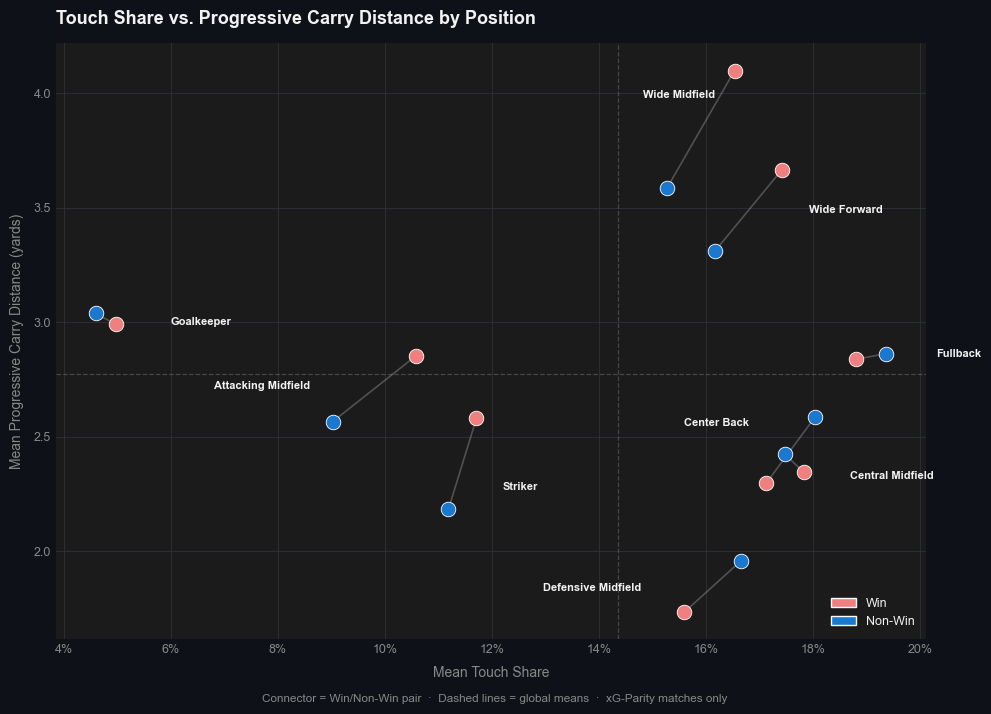

In [110]:
# ── Palette ───────────────────────────────────────────────────────────────────
BG_DARK   = "#0E1117"
BG_PANEL  = "#1B1B1B"
CORAL     = "lightcoral"
BLUE      = "#1A78CF"
WHITE     = "#F2F2F2"
GREY      = "#888888"
SPINE_COL = "#2E323A"

# ── Aggregate ─────────────────────────────────────────────────────────────────
touch_agg = (
    team_match_position_touches
    .groupby(["position_bin", "outcome_binary"])["touch_share"]
    .mean()
    .reset_index()
)

prog_agg = (
    carries_pd
    .groupby(["position_bin", "outcome_binary"])["mean_prog_distance"]
    .mean()
    .reset_index()
)

scatter_df = touch_agg.merge(
    prog_agg,
    on=["position_bin", "outcome_binary"],
    how="inner"
)

# Optional safety
scatter_df = scatter_df.dropna(subset=["touch_share", "mean_prog_distance"])
scatter_df = scatter_df.sort_values(["position_bin", "outcome_binary"])

# Split
wins    = scatter_df[scatter_df["outcome_binary"] == "Win"]
nonwins = scatter_df[scatter_df["outcome_binary"] == "Non-Win"]

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

# Grid + spines
ax.grid(axis="x", color=SPINE_COL, lw=0.6, zorder=0)
ax.grid(axis="y", color=SPINE_COL, lw=0.6, zorder=0)
for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COL)

# Mean lines
ax.axvline(scatter_df["touch_share"].mean(), color=GREY, lw=0.9, ls="--", alpha=0.4, zorder=1)
ax.axhline(scatter_df["mean_prog_distance"].mean(), color=GREY, lw=0.9, ls="--", alpha=0.4, zorder=1)

# ── Labels config ─────────────────────────────────────────────────────────────
label_cfg = {
    "Goalkeeper":          (0.060, 3.00, "left",   "center"),
    "Wide Midfield":       (0.155, 3.97, "center", "bottom"),
    "Wide Forward":        (0.193, 3.49, "right",  "center"),
    "Fullback":            (0.203, 2.86, "left",   "center"),
    "Attacking Midfield":  (0.086, 2.72, "right",  "center"),
    "Center Back":         (0.168, 2.56, "right",  "center"),
    "Central Midfield":    (0.187, 2.33, "left",   "center"),
    "Striker":             (0.122, 2.28, "left",   "center"),
    "Defensive Midfield":  (0.148, 1.84, "right",  "center"),
}

positions = sorted(scatter_df["position_bin"].unique())

# ── Plot per position ─────────────────────────────────────────────────────────
for pos in positions:
    grp = scatter_df[scatter_df["position_bin"] == pos]
    w_row = grp[grp["outcome_binary"] == "Win"]
    n_row = grp[grp["outcome_binary"] == "Non-Win"]

    if w_row.empty or n_row.empty:
        continue

    # FIXED extraction (this was your bug)
    wx = w_row["touch_share"].iloc[0]
    wy = w_row["mean_prog_distance"].iloc[0]
    nx = n_row["touch_share"].iloc[0]
    ny = n_row["mean_prog_distance"].iloc[0]

    cx, cy = (wx + nx) / 2, (wy + ny) / 2

    # connector line
    ax.plot([wx, nx], [wy, ny], color=WHITE, lw=1.2, alpha=0.25, zorder=2)

    # points
    ax.scatter(wx, wy, color=CORAL, s=110, zorder=5, edgecolors="white", linewidths=0.6)
    ax.scatter(nx, ny, color=BLUE,  s=110, zorder=5, edgecolors="white", linewidths=0.6)

    # labels
    lx, ly, ha, va = label_cfg.get(pos, (cx, cy + 0.1, "center", "bottom"))
    ax.text(lx, ly, pos, ha=ha, va=va,
            color=WHITE, fontsize=8, fontweight="bold", zorder=6)

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.tick_params(axis="x", colors=GREY, labelsize=9)
ax.tick_params(axis="y", colors=GREY, labelsize=9)

ax.set_xlabel("Mean Touch Share", color=GREY, fontsize=10, labelpad=7)
ax.set_ylabel("Mean Progressive Carry Distance (yards)", color=GREY, fontsize=10, labelpad=7)

# Title
ax.set_title(
    "Touch Share vs. Progressive Carry Distance by Position",
    color=WHITE, fontsize=13, fontweight="bold", loc="left", pad=14,
)

# Subtitle
fig.text(
    0.5, -0.01,
    "Connector = Win/Non-Win pair  ·  Dashed lines = global means  ·  xG-Parity matches only",
    ha="center", color=GREY, fontsize=8.5
)

# Legend
legend_handles = [
    mpatches.Patch(facecolor=CORAL, edgecolor="white", label="Win"),
    mpatches.Patch(facecolor=BLUE,  edgecolor="white", label="Non-Win"),
]

ax.legend(
    handles=legend_handles,
    loc="lower right",
    framealpha=0.15,
    facecolor=BG_PANEL,
    labelcolor=WHITE,
    fontsize=9,
    edgecolor=SPINE_COL
)

plt.tight_layout()
plt.show()

The scatter plot makes the independence tangible. If touch share and progressive 
distance were measuring the same thing, the positions would line up along a clear 
diagonal with high touch share predicting high progressive distance every time. Instead, 
the points scatter without pattern. Fullbacks have high touch share but modest 
progressive distance. Strikers have low touch share but carry aggressively when they 
do get the ball. The two dimensions simply do not track each other.

Winning teams in xG-parity matches make both of these choices differently from 
non-winning teams, and because the choices are independent, each one adds something 
the other cannot. We now have two distinct signals pointing in the same direction. 
The natural next step is to ask whether we can combine them into a single measure, 
and whether that measure actually predicts who wins.

## Putting It All Together

Two findings have emerged from this analysis. Winning teams in xG-parity matches hold 
the ball in more advanced positions. And they move the ball forward more aggressively 
when they have it. These are independent of each other; knowing one tells you almost 
nothing about the other.

The natural question is whether these two signals, taken together, can tell us something 
useful about who wins. Not perfectly, after all soccer is far too complex for any single metric 
to be a reliable oracle. But usefully. Meaningfully. Enough to suggest that positional 
structure is not just a statistical curiosity but a real tactical signal worth paying 
attention to.

To test this, we construct a single composite metric that captures both dimensions in 
one number, the Forward Possession Index (FPI).

The Forward Possession Index (FPI) is built from the positions which earned our 
confidence in the touch share analysis, specifically the five outfield positions 
that survived Bonferroni correction. We deliberately exclude Goalkeeper from this 
calculation. While goalkeeper touch share was statistically significant, it reflects 
a build-up style preference rather than a forward attacking posture, and including 
it would muddy the tactical interpretation of the index.

The construction is straightforward. FPI is the sum of touch shares in advanced 
outfield positions minus the sum of touch shares in defensive outfield positions:

    FPI = (Attacking Midfield + Wide Forward) − (Center Back + Defensive Midfield + Fullback)

A positive FPI means a team concentrates more possession in advanced areas than 
defensive ones. A negative FPI means the opposite. Most teams will have a negative 
FPI as there are simply more defensive and midfield players on a soccer pitch than 
attacking ones, so possession naturally skews toward the back. What matters is not 
the absolute value but whether winning teams consistently score higher than non-winning 
teams.

This is a deliberately simple construction. We are not building a predictive model,  
we are asking whether the structural pattern we identified statistically translates 
into a measurable signal at the match level.

In [111]:
# Pivot touch share to wide format for FPI calculation
touch_wide = (
    team_match_position_touches
    .pivot_table(
        index=['match_id', 'team', 'outcome_binary'],
        columns='position_bin',
        values='touch_share',
        aggfunc='mean'
    )
    .reset_index()
)

# Compute Forward Possession Index (FPI)
attacking = ['Attacking Midfield', 'Wide Forward']
defensive = ['Center Back', 'Defensive Midfield', 'Fullback']

touch_wide['FPI'] = (
    touch_wide[attacking].sum(axis=1) -
    touch_wide[defensive].sum(axis=1)
)

# Mann-Whitney U test on FPI
win_fpi = touch_wide[touch_wide['outcome_binary'] == 'Win']['FPI']
nonwin_fpi = touch_wide[touch_wide['outcome_binary'] == 'Non-Win']['FPI']

u_stat, p_val = mannwhitneyu(win_fpi, nonwin_fpi, alternative='two-sided')
d = cohens_d(win_fpi, nonwin_fpi)

# AUC
y_true = (touch_wide['outcome_binary'] == 'Win').astype(int)
auc = roc_auc_score(y_true, touch_wide['FPI'])

print("Forward Possession Index (FPI) Analysis")
print("=" * 50)
print(f"  Win mean FPI    : {win_fpi.mean():.4f}")
print(f"  Non-Win mean FPI: {nonwin_fpi.mean():.4f}")
print(f"  Difference      : {win_fpi.mean() - nonwin_fpi.mean():.4f}")
print(f"\nMann-Whitney U Test:")
print(f"  p-value     : {p_val:.4f}")
print(f"  Cohen's d   : {d:.4f}")
print(f"\nPredictive Signal:")
print(f"  AUC         : {auc:.4f}")
print(f"  Interpretation: {'Better than random' if auc > 0.5 else 'No predictive signal'}")


Forward Possession Index (FPI) Analysis
  Win mean FPI    : -0.3418
  Non-Win mean FPI: -0.3753
  Difference      : 0.0334

Mann-Whitney U Test:
  p-value     : 0.0006
  Cohen's d   : 0.2140

Predictive Signal:
  AUC         : 0.5577
  Interpretation: Better than random


Three numbers tell the story here, and each one adds a different layer of meaning.

The Mann-Whitney p-value of 0.0006 confirms that the difference in FPI between winners 
and non-winners is not a fluke. Across 1,302 team-match observations, winning teams 
consistently score higher on the Forward Possession Index than non-winning teams. The 
result is robust well beyond the standard significance threshold.

Cohen's d of 0.21 puts that difference in perspective. It is a small effect. It is real, 
but subtle. This is exactly what we would expect from a single composite metric applied 
to a sport as complex and low-scoring as soccer. No tactical signal should dominate 
outcomes completely. The fact that we detect a consistent small effect across 651 
matches is itself meaningful.

The AUC of 0.558 is the most important number to interpret carefully. It means that 
if we randomly selected one winning team-match and one non-winning team-match, FPI 
correctly identifies the winner about 56% of the time. A coin flip would be right 50% 
of the time. FPI moves that needle by 6 percentage points consistently, reliably, 
and across a large and varied sample of professional soccer matches.

That is not a crystal ball. It was never meant to be. What it is, is evidence that 
positional structure carries a real tactical signal in matches where expected goals 
cannot separate the teams. Winning teams play higher, move the ball more aggressively 
forward, and that combination of behaviors is detectable even in a single composite 
number built from five positional touch shares.

The question this raises is not whether positional structure matters, for we have 
established that it does. The question is how much richer the signal becomes when we 
move beyond a simple linear index and start asking whether distinct tactical archetypes 
exist within our data. That is the work that comes next.

## A Closer Look at Team-Level Tactical Profiles

The Forward Possession Index gives us a single number that predicts outcomes modestly 
but reliably. But FPI is built from only one dimension, touch share. Before closing, 
it is worth asking whether team-level summaries of how teams structure and progress 
play provide any additional separation between winners and non-winners.

We construct four team-level metrics that capture distinct aspects of tactical behavior, 
each aggregated to the team-match level across our 651 parity matches.

In [112]:
team_level = team_match_xg[["match_id", "team", "outcome"]].copy()

# ------------------------------------------------------------------
# 6) Wide progression share
# ------------------------------------------------------------------

progressive_events = events[events["match_id"].isin(team_match_xg["match_id"])].copy()

prog_events = progressive_events[progressive_events["type"].isin(["Pass", "Carry"])].copy()

prog_events["is_progressive"] = (
    ((prog_events["type"] == "Pass") &
     (prog_events["pass_end_location_x"] - prog_events["location_x"] >= 10)) |
    ((prog_events["type"] == "Carry") &
     (prog_events["carry_end_location_x"] - prog_events["location_x"] >= 10))
)

progressive_actions = prog_events[prog_events["is_progressive"]].copy()

def classify_zone(y):
    return "Wide" if (y < 20 or y > 60) else "Central"

progressive_actions["zone"] = progressive_actions["location_y"].apply(classify_zone)

team_prog_total = (
    progressive_actions
    .groupby(["match_id", "team"])
    .size()
    .reset_index(name="team_progressive_actions")
)

team_wide_prog = (
    progressive_actions[progressive_actions["zone"] == "Wide"]
    .groupby(["match_id", "team"])
    .size()
    .reset_index(name="wide_progressive_actions")
)

team_width = team_prog_total.merge(
    team_wide_prog,
    on=["match_id", "team"],
    how="left"
)

team_width["wide_progressive_actions"] = team_width["wide_progressive_actions"].fillna(0)

team_width["wide_progression_share"] = (
    team_width["wide_progressive_actions"] /
    team_width["team_progressive_actions"]
)

team_level = team_level.merge(
    team_width[["match_id", "team", "wide_progression_share"]],
    on=["match_id", "team"],
    how="left"
)

# ------------------------------------------------------------------
# 7) Build-up share
# ------------------------------------------------------------------

TOUCH_EVENTS = ["Ball Receipt*", "Pass", "Carry", "Dribble", "Shot"]

touches = events[
    (events["match_id"].isin(team_match_xg["match_id"])) &
    (events["type"].isin(TOUCH_EVENTS))
].copy()

touches["position_bin"] = touches["position"].map(POSITION_BIN_MAP)
touches = touches.dropna(subset=["position_bin"])

team_pos_touches = (
    touches
    .groupby(["match_id", "team", "position_bin"])
    .size()
    .reset_index(name="touches")
)

BUILD_UP = ["Center Back", "Fullback", "Defensive Midfield"]

team_pos_touches["phase"] = np.where(
    team_pos_touches["position_bin"].isin(BUILD_UP),
    "BuildUp",
    "Advanced"
)

team_phase = (
    team_pos_touches
    .groupby(["match_id", "team", "phase"])["touches"]
    .sum()
    .reset_index()
)

team_phase = (
    team_phase
    .pivot_table(
        index=["match_id", "team"],
        columns="phase",
        values="touches",
        fill_value=0
    )
    .reset_index()
)

team_phase["build_up_share"] = (
    team_phase["BuildUp"] /
    (team_phase["BuildUp"] + team_phase["Advanced"])
)

team_level = team_level.merge(
    team_phase[["match_id", "team", "build_up_share"]],
    on=["match_id", "team"],
    how="left"
)

# ------------------------------------------------------------------
# 8) Progression concentration
# ------------------------------------------------------------------

progressive_actions["position_bin"] = progressive_actions["position"].map(POSITION_BIN_MAP)
progressive_actions = progressive_actions.dropna(subset=["position_bin"])

team_match_position_progressions = (
    progressive_actions
    .groupby(["match_id", "team", "position_bin"])
    .size()
    .reset_index(name="progressive_actions")
)

team_match_progression_totals = (
    team_match_position_progressions
    .groupby(["match_id", "team"])["progressive_actions"]
    .sum()
    .reset_index(name="team_progressive_actions")
)

team_match_position_progressions = team_match_position_progressions.merge(
    team_match_progression_totals,
    on=["match_id", "team"],
    how="left"
)

team_match_position_progressions["progressive_share"] = (
    team_match_position_progressions["progressive_actions"] /
    team_match_position_progressions["team_progressive_actions"]
)

max_prog = (
    team_match_position_progressions
    .groupby(["match_id", "team"])["progressive_share"]
    .max()
    .reset_index(name="max_progression_share")
)

team_level = team_level.merge(
    max_prog,
    on=["match_id", "team"],
    how="left"
)

# ------------------------------------------------------------------
# 9) Central midfield control
# ------------------------------------------------------------------

MIDFIELD = ["Central Midfield", "Attacking Midfield"]

midfield = touches[
    touches["position_bin"].isin(MIDFIELD)
]

midfield_counts = (
    midfield
    .groupby(["match_id", "team"])
    .size()
    .reset_index(name="midfield_touches")
)

team_total_touches = (
    touches
    .groupby(["match_id", "team"])
    .size()
    .reset_index(name="team_touches")
)

midfield_share = midfield_counts.merge(
    team_total_touches,
    on=["match_id", "team"],
    how="left"
)

midfield_share["central_midfield_touch_share"] = (
    midfield_share["midfield_touches"] /
    midfield_share["team_touches"]
)

team_level = team_level.merge(
    midfield_share[["match_id", "team", "central_midfield_touch_share"]],
    on=["match_id", "team"],
    how="left"
)

# ------------------------------------------------------------------
# Final
# ------------------------------------------------------------------

team_level = team_level.sort_values(["match_id", "team"]).reset_index(drop=True)

team_level["outcome_binary"] = np.where(
    team_level["outcome"] == "Win",
    "Win",
    "Non-Win"
)

# display(team_level.head(2))
# print(team_level.shape)

In [113]:
metrics = [
    "wide_progression_share",
    "build_up_share",
    "max_progression_share",
    "central_midfield_touch_share"
]

print("Team-Level Statistical Tests (Win vs Non-Win)")
print("=" * 60)

for col in metrics:
    win = team_level[team_level["outcome_binary"] == "Win"][col].dropna()
    nonwin = team_level[team_level["outcome_binary"] == "Non-Win"][col].dropna()

    if len(win) == 0 or len(nonwin) == 0:
        print(f"{col}: insufficient data")
        continue

    stat, p = mannwhitneyu(win, nonwin, alternative="two-sided")
    sig = "✅" if p < 0.05 else "❌"
    print(f"  {col:<35} p = {p:.4f}  {sig}")

Team-Level Statistical Tests (Win vs Non-Win)
  wide_progression_share              p = 0.2828  ❌
  build_up_share                      p = 0.0000  ✅
  max_progression_share               p = 0.0008  ✅
  central_midfield_touch_share        p = 0.0059  ✅


Three of four team-level metrics show statistically significant differences between 
winners and non-winners. Build-up share and progression concentration are the strongest 
signals. Winning teams tend to have lower build-up share, meaning they concentrate 
fewer touches in defensive and build-up areas, and their progressive actions are more 
evenly distributed rather than concentrated in a single position.

Wide progression share does not differ significantly, reinforcing what we found earlier. 
It is the direction of movement that matters, not whether it happens wide or centrally.

Central midfield touch share shows a modest but significant difference, suggesting that 
involvement of central roles contributes to winning outcomes in ways that complement the 
positional structure findings from earlier sections.

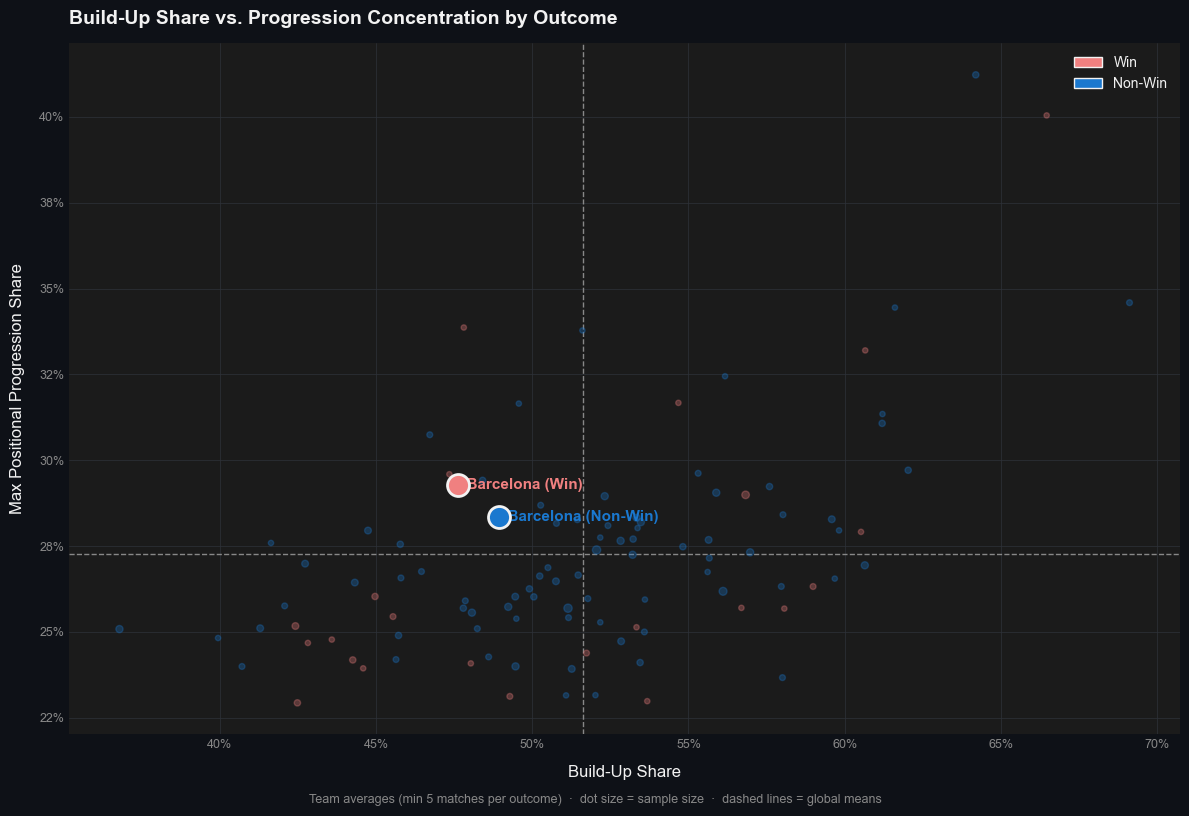

In [114]:
# ── 6B: Scatter — Build-Up Share × Progression Concentration (Team Level) ──────

HIGHLIGHT = "Barcelona"

team_agg = (
    team_level
    .groupby(["team", "outcome_binary"])
    .agg(
        build_up_share=("build_up_share", "mean"),
        max_progression_share=("max_progression_share", "mean"),
        n=("match_id", "count"),
    )
    .reset_index()
)
team_agg = team_agg[team_agg["n"] >= 5]

win_df    = team_agg[team_agg["outcome_binary"] == "Win"]
nonwin_df = team_agg[team_agg["outcome_binary"] == "Non-Win"]

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(BG_PANEL)

# Background teams
ax.scatter(
    nonwin_df[nonwin_df["team"] != HIGHLIGHT]["build_up_share"],
    nonwin_df[nonwin_df["team"] != HIGHLIGHT]["max_progression_share"],
    c=BLUE, alpha=0.3,
    s=nonwin_df[nonwin_df["team"] != HIGHLIGHT]["n"] * 3,
    zorder=2,
)
ax.scatter(
    win_df[win_df["team"] != HIGHLIGHT]["build_up_share"],
    win_df[win_df["team"] != HIGHLIGHT]["max_progression_share"],
    c=CORAL, alpha=0.3,
    s=win_df[win_df["team"] != HIGHLIGHT]["n"] * 3,
    zorder=2,
)

# Barcelona — solid with white edge
barca_nw = nonwin_df[nonwin_df["team"] == HIGHLIGHT]
barca_w  = win_df[win_df["team"] == HIGHLIGHT]

ax.scatter(
    barca_nw["build_up_share"], barca_nw["max_progression_share"],
    c=BLUE, s=250, zorder=5, edgecolors=WHITE, linewidths=2,
)
ax.scatter(
    barca_w["build_up_share"], barca_w["max_progression_share"],
    c=CORAL, s=250, zorder=5, edgecolors=WHITE, linewidths=2,
)

for _, row in barca_w.iterrows():
    ax.annotate(
        "  Barcelona (Win)",
        (row["build_up_share"], row["max_progression_share"]),
        color=CORAL, fontsize=11, va="center", fontweight="bold",
    )
for _, row in barca_nw.iterrows():
    ax.annotate(
        "  Barcelona (Non-Win)",
        (row["build_up_share"], row["max_progression_share"]),
        color=BLUE, fontsize=11, va="center", fontweight="bold",
    )

# Reference lines at global means
ax.axvline(team_agg["build_up_share"].mean(), color=GREY, lw=1, ls="--", zorder=1)
ax.axhline(team_agg["max_progression_share"].mean(), color=GREY, lw=1, ls="--", zorder=1)

# Axes
ax.set_xlabel("Build-Up Share", color=WHITE, fontsize=12, labelpad=10)
ax.set_ylabel("Max Positional Progression Share", color=WHITE, fontsize=12, labelpad=10)
ax.tick_params(colors=GREY, labelsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
for spine in ax.spines.values():
    spine.set_edgecolor(SPINE_COL)
ax.grid(axis="both", color=SPINE_COL, lw=0.5, zorder=0)

ax.set_title(
    "Build-Up Share vs. Progression Concentration by Outcome",
    color=WHITE, fontsize=14, fontweight="bold", pad=14, loc="left",
)
fig.text(
    0.5, -0.01,
    "Team averages (min 5 matches per outcome)  ·  dot size = sample size  ·  dashed lines = global means",
    ha="center", color=GREY, fontsize=9,
)

legend_handles = [
    mpatches.Patch(facecolor=CORAL, edgecolor=WHITE, label="Win"),
    mpatches.Patch(facecolor=BLUE,  edgecolor=WHITE, label="Non-Win"),
]
ax.legend(handles=legend_handles, facecolor=BG_PANEL, edgecolor=SPINE_COL, labelcolor=WHITE, fontsize=10)

plt.tight_layout()
plt.show()

The Barcelona highlight is instructive. As the most represented team in the StatsBomb 
dataset, Barcelona's win and non-win clusters sit in distinct quadrants of the chart. 
Lower build-up share and higher progression concentration when winning, higher build-up 
share and lower concentration when not. Even for a single team, the tactical fingerprint 
shifts meaningfully between outcomes.

Taken together, the team-level metrics reinforce and extend the positional findings from 
earlier sections. Structure matters. Concentration matters. Spatial distribution does not. 
These are consistent findings across multiple analytical lenses, and that consistency 
is what gives them credibility.

## What We Found, and What We Did Not

This analysis set out to answer a specific question: in professional soccer matches 
where both teams create nearly identical scoring chances, what separates the teams 
that win from the teams that do not?

The answer is positional structure but with an important qualifier. It is a real 
signal, not a complete explanation.

Across 651 xG-parity matches drawn from 3,464 professional games, we find consistent 
evidence that winning teams organize their possession differently. They hold the ball 
in more advanced positions, concentrating touches in attacking midfield and wide forward 
areas while ceding ground in defensive positions. They also move the ball more 
aggressively forward when they have it, gaining more progressive carry distance in 
attacking areas. And crucially, these two behaviors are statistically independent of 
each other: they are not two descriptions of the same tactical choice, but two 
distinct dimensions of how winning teams play.

When combined into a single Forward Possession Index, these signals predict match 
outcomes better than chance across a large and varied sample of professional matches. 
Not dramatically better. Not perfectly. But consistently and reliably. And that 
consistency, sustained across seven statistical tests and multiple layers of scrutiny, 
is what gives these findings their weight.

What we did not find is equally important to state clearly. We did not find that 
positional structure determines outcomes. Soccer matches are decided by dozens of 
factors: individual brilliance, set pieces, referee decisions, fatigue, game state, 
and genuine randomness that no tactical metric can fully account for. An AUC of 0.558 
leaves enormous room for all of those factors. Positional structure is one piece of a 
complex puzzle, not the puzzle itself.

We also did not find that the spatial distribution of forward movement matters,  
whether teams progress the ball through wide areas or centrally makes no significant 
difference in outcomes. What matters is the direction of movement, not its lateral 
location. Winners play higher and drive forward. Where exactly on the pitch they do 
this is, at least within our data, beside the point.

There are real limitations to acknowledge. The StatsBomb open dataset covers select 
competitions and seasons, weighted heavily toward elite European club soccer -- and 
notably toward Barcelona, whose extensive coverage in the dataset may influence 
positional patterns in ways that do not generalize to all styles of play. These 
findings should be interpreted with that skew in mind.

Our analysis is observational. We identify associations, not causes. The most 
significant confound is the scoreboard effect: a team that takes an early lead may 
naturally shift possession higher as the opposition chases the game, meaning some of 
what we are measuring could be a consequence of winning rather than a cause of it. We 
do not currently control for game state, and this remains an open limitation.

We also do not adjust for home and away bias or relative team strength. We assume that 
the xG-parity filter acts as a sufficient equalizer for those factors. Teams with 
similar xG totals are, by definition, performing similarly on the night. But this 
assumption may not hold in all cases. A team with significantly higher market value 
playing away from home may generate equal xG through very different tactical means 
than a lower-ranked home side.

These limitations do not undermine the findings. They frame them honestly. Positional 
structure is a measurable, consistent, statistically robust signal in xG-parity matches. 
The next step is to ask whether distinct tactical archetypes exist within our data 
(clusters of teams that share similar positional profiles) and whether those archetypes 
predict outcomes more powerfully than a simple linear index can. That is a richer, more 
nuanced question, and it is exactly where this analysis points.

Positional structure is not the full answer. But it is a better starting point than 
anything xG alone can offer in closely contested matches. For coaches, analysts, and 
anyone trying to understand why soccer matches end the way they do, that is not a 
small thing. It is exactly the kind of signal that separates tactical intuition from 
tactical evidence.

---

## Appendix

The following sections provide supplementary reference material for readers who wish 
to understand the data sources, variable definitions, and technical environment 
underlying this analysis.

---

### References

#### Data Sources
StatsBomb. (2024). *Open Data Repository*. GitHub. 
https://github.com/statsbomb/open-data

StatsBomb. (2024). *Open Data Events v4.0.0 Specification*. 
https://github.com/statsbomb/open-data/blob/master/doc/Open%20Data%20Events%20v4.0.0.pdf

Carrasquilla, L. (2026). Complete guide on working with the StatsBomb Open Data dataset. 
*Medium*. https://medium.com/@lucascarrasquillaparra/complete-guide-on-working-with-the-statsbomb-open-data-dataset-a57c26d5852b

#### Expected Goals (xG)
Rathke, A. (2017). An examination of expected goals and shot efficiency in soccer. 
*Journal of Human Sport and Exercise*, 12(2), 514-529.

Mead, J., O'Hare, A., & McMenemy, P. (2023). Expected goals in football: Improving 
model performance and demonstrating value. *PLOS ONE*, 18(4), e0282295. 
https://doi.org/10.1371/journal.pone.0282295

Green, S. (2012). Assessing the performance of Premier League goalscorers. 
*StatsBomb Blog*. https://statsbomb.com/articles/soccer/

Anzer, G., & Bauer, P. (2021). A goal scoring probability model for shots based on 
synchronized positional and event data in football (soccer). *Frontiers in Sports 
and Active Living*, 3, 624475.

Fernández, J., Bornn, L., & Cervone, D. (2021). A framework for the fine-grained 
evaluation of the instantaneous expected value of soccer possessions. *Machine 
Learning*, 110(6), 1389-1427.

#### Tactical Analysis
Memmert, D., Lemmink, K. A., & Sampaio, J. (2017). Current approaches to tactical 
performance analyses in soccer using position data. *Sports Medicine*, 47(1), 1-10.

Romero Clavijo, F. A., Drews, R., Denardi, R. A., Travassos, B., & Corrêa, U. C. 
(2024). Identification of football teams styles of play by cluster analysis. 
*International Journal of Performance Analysis in Sport*, 24(1), 123-142. 
https://doi.org/10.1177/17479541231186796

#### Statistical Methods
Mann, H. B., & Whitney, D. R. (1947). On a test of whether one of two random 
variables is stochastically larger than the other. *Annals of Mathematical 
Statistics*, 18(1), 50-60.

Wilcoxon, F. (1945). Individual comparisons by ranking methods. 
*Biometrics Bulletin*, 1(6), 80-83.

Cohen, J. (1988). *Statistical Power Analysis for the Behavioral Sciences* (2nd ed.). 
Lawrence Erlbaum Associates.

#### Python Libraries
McKinney, W. (2010). Data structures for statistical computing in Python. In 
*Proceedings of the 9th Python in Science Conference* (Vol. 445, pp. 51-56).

Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). Array programming 
with NumPy. *Nature*, 585(7825), 357-362.

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science 
& Engineering*, 9(3), 90-95.

Rowlinson, A. (2023). *mplsoccer: A Python library for plotting soccer/football 
charts in Matplotlib*. Version 1.3.0. https://mplsoccer.readthedocs.io/

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., 
... & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of 
Machine Learning Research*, 12, 2825-2830.

### Data Dictionary

**Source Variables (StatsBomb)**
- `match_id` -- Unique identifier for each match
- `team` -- Team name
- `type` -- Event type (Pass, Carry, Shot, etc.)
- `position` -- StatsBomb granular position label for the player involved
- `shot_statsbomb_xg` -- Expected goals value assigned to each shot event
- `location_x` -- Horizontal pitch coordinate of event (0 to 120)
- `carry_end_location_x` -- Horizontal pitch coordinate of carry endpoint

**Constructed Variables**
- `xg_diff` -- Absolute difference in total xG between the two teams in a match
- `xg_category` -- Bucketed xG difference: Parity (≤0.3), Close (0.3-0.7), 
   Moderate (0.7-1.5), Dominant (>1.5)
- `position_bin` -- Nine-category positional grouping mapped from StatsBomb positions:
  Goalkeeper, Center Back, Fullback, Defensive Midfield, Central Midfield, 
  Wide Midfield, Attacking Midfield, Wide Forward, Striker
- `touch_share` -- Proportion of a team's total touches taken by each positional group 
  within a match: touches_in_position / total_team_touches
- `progressive_distance` -- Yards gained toward the opponent's goal on a carry event: 
  carry_end_location_x minus location_x
- `mean_prog_distance` -- Mean progressive distance per carry aggregated at the 
  team-match-position level
- `outcome_binary` -- Simplified match outcome: Win or Non-Win (Draw + Loss combined)
- `FPI` -- Forward Possession Index: (Attacking Midfield + Wide Forward touch share) 
  minus (Center Back + Defensive Midfield + Fullback touch share)

### Data Quality Verification

The StatsBomb event dataset is highly sparse by design, as most columns are event-conditional.
Fields related to shots, goalkeeper actions, substitutions, disciplinary events, and relational links
(e.g., assisted shots) are only populated when the corresponding event type occurs.

As a result, columns such as `shot_statsbomb_xg`, `goalkeeper_*`, and `substitution_*` exhibit high
missingness due to event rarity rather than data quality issues.

Core identifiers, timestamps, team labels, and possession fields show no missingness, confirming the
structural integrity of the dataset. Spatial fields and player metadata are nearly complete, with
minor missingness attributable to off-camera or administrative events.

No global imputation or row-level filtering is required at this stage; subsequent analyses will
filter by event type and operate only on contextually relevant fields.

In [115]:
print("Data Completeness Check:")
print("=" * 60)

missing_matches = matches[["match_id", "home_score", "away_score"]].isnull().sum()
print("Matches - Missing values:")
print(missing_matches)

missing_events = events[["match_id", "type", "team"]].isnull().sum()
print("\nEvents - Missing values:")
print(missing_events)

duplicate_matches = matches[matches.duplicated(subset=["match_id"], keep=False)]
print(f"\nDuplicate matches: {duplicate_matches['match_id'].nunique()}")

print("=" * 60)
print("Data quality check complete")

Data Completeness Check:
Matches - Missing values:
match_id      0
home_score    0
away_score    0
dtype: int64

Events - Missing values:
match_id    0
type        0
team        0
dtype: int64

Duplicate matches: 0
Data quality check complete


### Limitations

- **Dataset scope:** StatsBomb open data covers a subset of competitions and seasons, 
  primarily at the elite level. Results may not generalize across all leagues or levels.
- **Causality:** The analysis is correlational. Observed patterns may reflect game state 
  (teams behave differently when leading) rather than purely pre-match tactical intent.
- **xG threshold choice:** The 0.3 threshold defines parity but is not uniquely optimal; 
  results may vary under alternative definitions.
- **Model simplicity:** The Forward Possession Index and team-level metrics are intentionally 
  simple summaries. More complex models incorporating interactions and temporal dynamics 
  may yield stronger predictive performance.

  This analysis is observational. We do not control for contextual factors such as red cards, home vs. away status, team strength, or game state (e.g., whether a team is leading or trailing). Additionally, team observations within the same match are not independent, which may influence statistical significance and should be considered when interpreting results. 

### Reproducibility

This analysis was conducted in Python 3.11. The following packages are required 
to reproduce all results:

- `pandas` -- Data manipulation and aggregation
- `numpy` -- Numerical operations
- `scipy` -- Statistical tests (Mann-Whitney U, Wilcoxon, Spearman, chi-square)
- `sklearn` -- AUC calculation
- `matplotlib` -- Visualizations
- `mplsoccer` -- Soccer pitch visualizations

All data is sourced from the StatsBomb open data repository. Raw parquet files 
should be placed at `../data/raw/Statsbomb/` relative to this notebook.

Full source code, data pipeline, and project documentation are available in the 
project repository on GitHub.

### Implications and Next Steps

This analysis shows that **not all tactical features are equally informative**. Structure and 
role-based behavior consistently matter, while spatial distribution does not. Importantly, 
aggregating to the team level produces clearer and more stable signals than isolated 
event-level metrics.

A natural next step (outside the scope of this course) is to move from individual metrics to **holistic tactical profiles**:

- **Clustering:** Identify archetypes of team behavior based on structure, progression, and concentration  
- **Archetype outcomes:** Test whether certain tactical profiles win more consistently  
- **Modeling:** Build predictive models using combined team-level features  
- **Validation:** Evaluate robustness on out-of-sample or temporal splits 

*This notebook serves as the analytical foundation for Team 4's Georgia Tech MSA Spring 
2026 Practicum final deliverable. All code and instructions are available in the project repository.*